In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


In [16]:
print('=' * 60)
print('ЗАГРУЗКА ДАННЫХ')
print('=' * 60)

# Файл с датасетом должен лежать в той же папке, что и ноутбук.
DATA_PATH = 'Customer-Churn-Records.csv'

df = pd.read_csv(DATA_PATH)

target = 'Exited'

# Сначала отделяем финальную test-выборку.
# Она не используется для подбора порога, только для итоговой проверки.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[target]
)

print(f'Размер исходного датасета: {df.shape}')
print(f'Размер train: {train_df.shape}')
print(f'Размер test: {test_df.shape}')
print('\nПервые 5 строк train:')
display(train_df.head())


ЗАГРУЗКА ДАННЫХ
Размер исходного датасета: (10000, 18)
Размер train: (8000, 18)
Размер test: (2000, 18)

Первые 5 строк train:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
4791,4792,15746461,Taylor,709,Spain,Male,35,2,0.00,2,1,0,104982.39,0,0,2,GOLD,422
8881,8882,15618647,Kornilova,744,France,Male,29,1,43504.42,1,1,1,119327.75,0,0,1,PLATINUM,607
6166,6167,15567431,Kodilinyechukwu,773,France,Male,64,2,145578.28,1,0,1,186172.85,0,0,1,SILVER,630
4473,4474,15713532,Wang,646,Germany,Female,29,4,105957.44,1,1,0,15470.91,0,0,1,PLATINUM,345
854,855,15601589,Baresi,675,France,Female,57,8,0.00,2,0,1,95463.29,0,0,3,SILVER,632


In [ ]:
print('\n' + '=' * 60)
print('ПРЕДОБРАБОТКА ДАННЫХ')
print('=' * 60)

# Удаляем явно бесполезные и потенциально "читерские" признаки.
columns_to_drop = [
    'RowNumber', 'CustomerId', 'Surname',
    'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned'
]

for col in columns_to_drop:
    if col in train_df.columns:
        train_df = train_df.drop(columns=[col])
        test_df = test_df.drop(columns=[col])
        print(f'✓ Удален признак: {col}')

train_df = train_df.dropna(subset=[target]).copy()
test_df = test_df.dropna(subset=[target]).copy()

X_train_full = train_df.drop(columns=[target]).copy()
y_train_full = train_df[target].copy()
X_test = test_df.drop(columns=[target]).copy()
y_test = test_df[target].copy()

print('\nРаспределение классов в train:')
print(y_train_full.value_counts(normalize=True).round(4))
print('\nРаспределение классов в test:')
print(y_test.value_counts(normalize=True).round(4))

categorical_cols = X_train_full.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train_full.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print(f'\nКатегориальные признаки: {categorical_cols}')
print(f'Числовые признаки: {numerical_cols}')

print('\nПроверка пропусков в train:')
print(X_train_full.isnull().sum())

if numerical_cols:
    num_imputer = SimpleImputer(strategy='median')
    X_train_full[numerical_cols] = num_imputer.fit_transform(X_train_full[numerical_cols])
    X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])
    print('\n✓ Пропуски в числовых признаках заполнены медианой')

if categorical_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_full[categorical_cols] = cat_imputer.fit_transform(X_train_full[categorical_cols])
    X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])
    print('✓ Пропуски в категориальных признаках заполнены модой')

# One-Hot Encoding лучше, чем LabelEncoder, особенно для Logistic Regression.
X_train_full = pd.get_dummies(X_train_full, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train_full, X_test = X_train_full.align(X_test, join='left', axis=1, fill_value=0)

# Отдельная validation-выборка нужна для подбора порога.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# Масштабирование нужно только для Logistic Regression.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_valid_scaled = pd.DataFrame(scaler.transform(X_valid), columns=X_valid.columns, index=X_valid.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f'\nРазмер X_train: {X_train.shape}')
print(f'Размер X_valid: {X_valid.shape}')
print(f'Размер X_test: {X_test.shape}')
print('\n✓ Предобработка завершена')



ПРЕДОБРАБОТКА ДАННЫХ
✓ Удален признак: RowNumber
✓ Удален признак: CustomerId
✓ Удален признак: Surname
✓ Удален признак: Complain
✓ Удален признак: Satisfaction Score
✓ Удален признак: Card Type
✓ Удален признак: Point Earned

Распределение классов в train:
Exited
0    0.7962
1    0.2037
Name: proportion, dtype: float64

Распределение классов в test:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64

Категориальные признаки: ['Geography', 'Gender']
Числовые признаки: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Проверка пропусков в train:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

✓ Пропуски в числовых признаках заполнены медианой
✓ Пропуски в категориальных признаках заполнены модой

Размер X_train: (6400, 11)
Размер X_valid: (

In [18]:
print('\n' + '=' * 60)
print('ФУНКЦИИ ДЛЯ ОЦЕНКИ И ПОДБОРА ПОРОГА')
print('=' * 60)

def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

def evaluate_model(name, y_true, y_pred, y_proba):
    metrics = get_metrics(y_true, y_pred, y_proba)
    print(f'\n{name}')
    print('-' * 40)
    for metric_name, value in metrics.items():
        print(f'{metric_name:10s}: {value:.4f}')
    return metrics

def threshold_table(model_name, y_true, y_proba, thresholds=np.arange(0.30, 0.81, 0.01)):
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        row = get_metrics(y_true, y_pred, y_proba)
        row['Model'] = model_name
        row['Threshold'] = round(float(threshold), 2)
        rows.append(row)
    return pd.DataFrame(rows)

def choose_best_threshold(threshold_df, min_recall=0.55):
    # Выбираем порог так, чтобы повысить Precision, но не уронить Recall слишком сильно.
    # Если вариантов с Recall >= min_recall нет, выбираем лучший вариант по F1-Score.
    candidates = threshold_df[threshold_df['Recall'] >= min_recall].copy()
    if len(candidates) == 0:
        candidates = threshold_df.copy()
    candidates = candidates.sort_values(by=['Precision', 'F1-Score', 'Accuracy'], ascending=False)
    return candidates.iloc[0]

# Полный вес положительного класса часто слишком сильно поднимает Recall и снижает Precision.
# Поэтому используем мягкую балансировку через квадратный корень.
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
scale_pos_weight_soft = np.sqrt(scale_pos_weight)

print(f'Полный scale_pos_weight: {scale_pos_weight:.2f}')
print(f'Мягкий scale_pos_weight: {scale_pos_weight_soft:.2f}')



ФУНКЦИИ ДЛЯ ОЦЕНКИ И ПОДБОРА ПОРОГА
Полный scale_pos_weight: 3.91
Мягкий scale_pos_weight: 1.98


In [19]:
print('\n' + '=' * 60)
print('ОБУЧЕНИЕ МОДЕЛЕЙ С МЯГКОЙ БАЛАНСИРОВКОЙ')
print('=' * 60)

models = {}
valid_proba = {}
test_proba = {}
default_results = {}

print('\nОбучение Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight={0: 1, 1: 2})
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr
valid_proba['Logistic Regression'] = lr.predict_proba(X_valid_scaled)[:, 1]
test_proba['Logistic Regression'] = lr.predict_proba(X_test_scaled)[:, 1]
default_results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', y_test,
    (test_proba['Logistic Regression'] >= 0.5).astype(int),
    test_proba['Logistic Regression']
)

print('\nОбучение Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight={0: 1, 1: 2},
    n_jobs=-1,
    max_depth=10,
    min_samples_leaf=3
)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
valid_proba['Random Forest'] = rf.predict_proba(X_valid)[:, 1]
test_proba['Random Forest'] = rf.predict_proba(X_test)[:, 1]
default_results['Random Forest'] = evaluate_model(
    'Random Forest', y_test,
    (test_proba['Random Forest'] >= 0.5).astype(int),
    test_proba['Random Forest']
)

print('\nОбучение XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    random_state=42,
    scale_pos_weight=scale_pos_weight_soft,
    eval_metric='logloss',
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
valid_proba['XGBoost'] = xgb_model.predict_proba(X_valid)[:, 1]
test_proba['XGBoost'] = xgb_model.predict_proba(X_test)[:, 1]
default_results['XGBoost'] = evaluate_model(
    'XGBoost', y_test,
    (test_proba['XGBoost'] >= 0.5).astype(int),
    test_proba['XGBoost']
)

print('\nОбучение LightGBM...')
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    random_state=42,
    class_weight={0: 1, 1: 2},
    verbose=-1,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
lgb_model.fit(X_train, y_train)
models['LightGBM'] = lgb_model
valid_proba['LightGBM'] = lgb_model.predict_proba(X_valid)[:, 1]
test_proba['LightGBM'] = lgb_model.predict_proba(X_test)[:, 1]
default_results['LightGBM'] = evaluate_model(
    'LightGBM', y_test,
    (test_proba['LightGBM'] >= 0.5).astype(int),
    test_proba['LightGBM']
)

print('\nОбучение Gradient Boosting...')
gb = GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=4, learning_rate=0.05)
gb.fit(X_train, y_train)
models['Gradient Boosting'] = gb
valid_proba['Gradient Boosting'] = gb.predict_proba(X_valid)[:, 1]
test_proba['Gradient Boosting'] = gb.predict_proba(X_test)[:, 1]
default_results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting', y_test,
    (test_proba['Gradient Boosting'] >= 0.5).astype(int),
    test_proba['Gradient Boosting']
)

print('\nОбучение CatBoost...')
cat = CatBoostClassifier(
    iterations=300,
    random_state=42,
    verbose=0,
    depth=5,
    learning_rate=0.05,
    class_weights=(1, 2)
)
cat.fit(X_train, y_train)
models['CatBoost'] = cat
valid_proba['CatBoost'] = cat.predict_proba(X_valid)[:, 1]
test_proba['CatBoost'] = cat.predict_proba(X_test)[:, 1]
default_results['CatBoost'] = evaluate_model(
    'CatBoost', y_test,
    (test_proba['CatBoost'] >= 0.5).astype(int),
    test_proba['CatBoost']
)



ОБУЧЕНИЕ МОДЕЛЕЙ С МЯГКОЙ БАЛАНСИРОВКОЙ

Обучение Logistic Regression...

Logistic Regression
----------------------------------------
Accuracy  : 0.8025
Precision : 0.5177
Recall    : 0.4657
F1-Score  : 0.4903
ROC-AUC   : 0.7790

Обучение Random Forest...

Random Forest
----------------------------------------
Accuracy  : 0.8555
Precision : 0.6725
Recall    : 0.5686
F1-Score  : 0.6162
ROC-AUC   : 0.8719

Обучение XGBoost...

XGBoost
----------------------------------------
Accuracy  : 0.8455
Precision : 0.6187
Recall    : 0.6324
F1-Score  : 0.6255
ROC-AUC   : 0.8762

Обучение LightGBM...

LightGBM
----------------------------------------
Accuracy  : 0.8480
Precision : 0.6256
Recall    : 0.6348
F1-Score  : 0.6302
ROC-AUC   : 0.8686

Обучение Gradient Boosting...

Gradient Boosting
----------------------------------------
Accuracy  : 0.8660
Precision : 0.7555
Recall    : 0.5074
F1-Score  : 0.6070
ROC-AUC   : 0.8721

Обучение CatBoost...

CatBoost
---------------------------------------

In [20]:
print('\n' + '=' * 60)
print('СВОДНАЯ ТАБЛИЦА: СТАНДАРТНЫЙ ПОРОГ 0.5')
print('=' * 60)

default_results_df = pd.DataFrame(default_results).T
display(default_results_df.sort_values('Precision', ascending=False).round(4))



СВОДНАЯ ТАБЛИЦА: СТАНДАРТНЫЙ ПОРОГ 0.5


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Gradient Boosting,0.8660,0.7555,0.5074,0.6070,0.8721
Random Forest,0.8555,0.6725,0.5686,0.6162,0.8719
CatBoost,0.8525,0.6402,0.6324,0.6363,0.8779
LightGBM,0.8480,0.6256,0.6348,0.6302,0.8686
XGBoost,0.8455,0.6187,0.6324,0.6255,0.8762
Logistic Regression,0.8025,0.5177,0.4657,0.4903,0.7790


In [21]:
print('\n' + '=' * 60)
print('ПОДБОР ПОРОГОВ ПО VALIDATION-ВЫБОРКЕ')
print('=' * 60)

all_threshold_tables = []
best_threshold_rows = []
tuned_results = {}
tuned_predictions = {}

# Минимальный Recall можно менять.
# Чем выше значение, тем меньше упадет Recall, но тем сложнее сильно поднять Precision.
MIN_RECALL = 0.55

for name in models.keys():
    valid_table = threshold_table(name, y_valid, valid_proba[name])
    all_threshold_tables.append(valid_table)
    best_row = choose_best_threshold(valid_table, min_recall=MIN_RECALL)
    best_threshold = float(best_row['Threshold'])
    best_threshold_rows.append(best_row)
    y_pred_tuned = (test_proba[name] >= best_threshold).astype(int)
    tuned_predictions[name] = y_pred_tuned
    tuned_results[name] = get_metrics(y_test, y_pred_tuned, test_proba[name])
    tuned_results[name]['Threshold'] = best_threshold

threshold_results_df = pd.concat(all_threshold_tables, ignore_index=True)
best_thresholds_df = pd.DataFrame(best_threshold_rows).set_index('Model')
tuned_results_df = pd.DataFrame(tuned_results).T

print(f'Порог подбирался на validation-выборке при условии Recall >= {MIN_RECALL}')
print('\nЛучшие пороги по validation-выборке:')
display(best_thresholds_df[['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4))

print('\nИтоговые результаты на test после подбора порога:')
display(tuned_results_df.sort_values('Precision', ascending=False).round(4))



ПОДБОР ПОРОГОВ ПО VALIDATION-ВЫБОРКЕ
Порог подбирался на validation-выборке при условии Recall >= 0.55

Лучшие пороги по validation-выборке:


,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,,
Logistic Regression,0.43,0.7712,0.4500,0.5521,0.4959,0.7702
Random Forest,0.49,0.8481,0.6456,0.5644,0.6023,0.8546
XGBoost,0.58,0.8538,0.6704,0.5552,0.6074,0.8588
LightGBM,0.58,0.8525,0.6667,0.5521,0.6040,0.8562
Gradient Boosting,0.42,0.8569,0.6844,0.5521,0.6112,0.8577
CatBoost,0.60,0.8638,0.7030,0.5736,0.6318,0.8626



Итоговые результаты на test после подбора порога:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Threshold
CatBoost,0.8650,0.7104,0.5711,0.6332,0.8779,0.60
XGBoost,0.8620,0.6953,0.5760,0.6300,0.8762,0.58
LightGBM,0.8615,0.6944,0.5735,0.6282,0.8686,0.58
Gradient Boosting,0.8605,0.6891,0.5760,0.6275,0.8721,0.42
Random Forest,0.8535,0.6602,0.5809,0.6180,0.8719,0.49
Logistic Regression,0.7770,0.4626,0.5760,0.5131,0.7790,0.43


In [22]:
print('\n' + '=' * 60)
print('СРАВНЕНИЕ ДО И ПОСЛЕ ПОДБОРА ПОРОГА')
print('=' * 60)

comparison_rows = []
for name in models.keys():
    before = default_results_df.loc[name]
    after = tuned_results_df.loc[name]
    comparison_rows.append({
        'Model': name,
        'Threshold_before': 0.50,
        'Threshold_after': after['Threshold'],
        'Precision_before': before['Precision'],
        'Precision_after': after['Precision'],
        'Precision_delta': after['Precision'] - before['Precision'],
        'Recall_before': before['Recall'],
        'Recall_after': after['Recall'],
        'Recall_delta': after['Recall'] - before['Recall'],
        'F1_before': before['F1-Score'],
        'F1_after': after['F1-Score'],
        'F1_delta': after['F1-Score'] - before['F1-Score'],
        'Accuracy_before': before['Accuracy'],
        'Accuracy_after': after['Accuracy'],
        'Accuracy_delta': after['Accuracy'] - before['Accuracy']
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
display(comparison_df.sort_values('Precision_after', ascending=False).round(4))

print('\nВажно: Precision почти всегда растет за счет некоторого снижения Recall.')
print('Задача подбора порога — найти компромисс, при котором Precision выше, а остальные метрики проседают минимально.')



СРАВНЕНИЕ ДО И ПОСЛЕ ПОДБОРА ПОРОГА


,Threshold_before,Threshold_after,Precision_before,Precision_after,Precision_delta,Recall_before,Recall_after,Recall_delta,F1_before,F1_after,F1_delta,Accuracy_before,Accuracy_after,Accuracy_delta
Model,,,,,,,,,,,,,,
CatBoost,0.5,0.60,0.6402,0.7104,0.0702,0.6324,0.5711,-0.0613,0.6363,0.6332,-0.0031,0.8525,0.8650,0.0125
XGBoost,0.5,0.58,0.6187,0.6953,0.0766,0.6324,0.5760,-0.0564,0.6255,0.6300,0.0046,0.8455,0.8620,0.0165
LightGBM,0.5,0.58,0.6256,0.6944,0.0688,0.6348,0.5735,-0.0613,0.6302,0.6282,-0.0020,0.8480,0.8615,0.0135
Gradient Boosting,0.5,0.42,0.7555,0.6891,-0.0663,0.5074,0.5760,0.0686,0.6070,0.6275,0.0205,0.8660,0.8605,-0.0055
Random Forest,0.5,0.49,0.6725,0.6602,-0.0123,0.5686,0.5809,0.0123,0.6162,0.6180,0.0018,0.8555,0.8535,-0.0020
Logistic Regression,0.5,0.43,0.5177,0.4626,-0.0551,0.4657,0.5760,0.1103,0.4903,0.5131,0.0228,0.8025,0.7770,-0.0255



Важно: Precision почти всегда растет за счет некоторого снижения Recall.
Задача подбора порога — найти компромисс, при котором Precision выше, а остальные метрики проседают минимально.


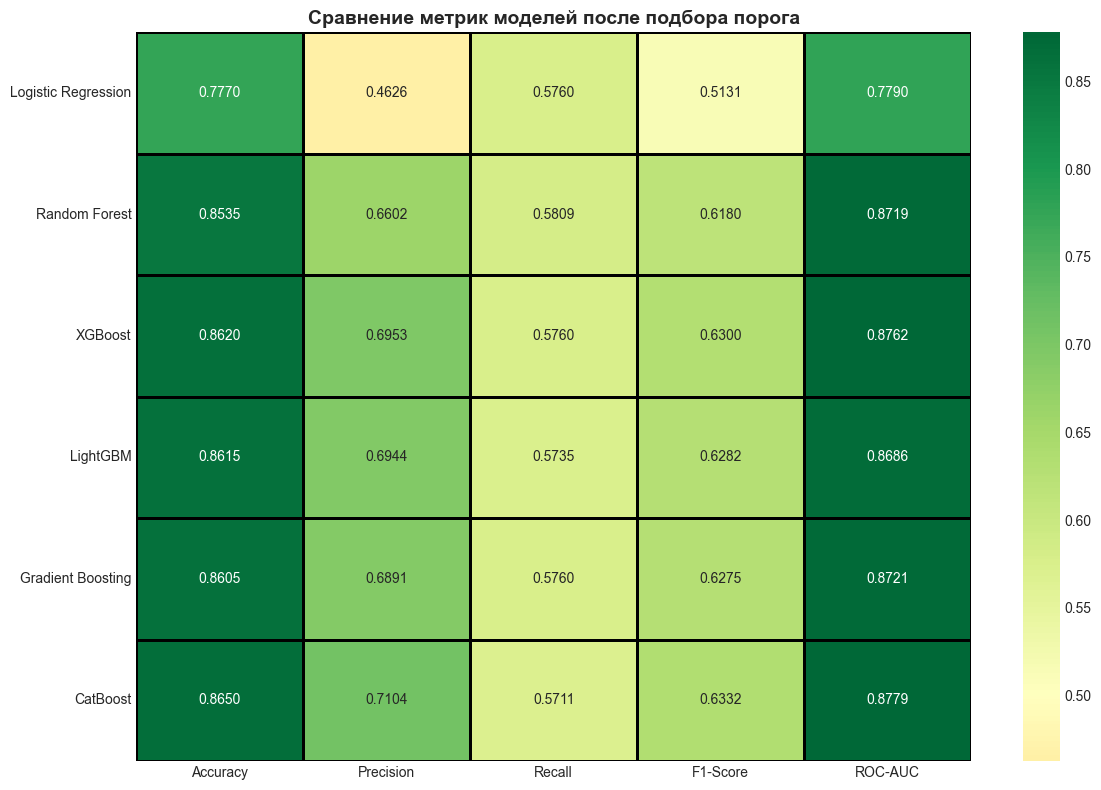

In [23]:
# Тепловая карта итоговых метрик после подбора порога
plot_df = tuned_results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].copy()

plt.figure(figsize=(12, 8))
sns.heatmap(plot_df.round(4), annot=True, cmap='RdYlGn', center=0.5, fmt='.4f', linewidths=1, linecolor='black')
plt.title('Сравнение метрик моделей после подбора порога', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


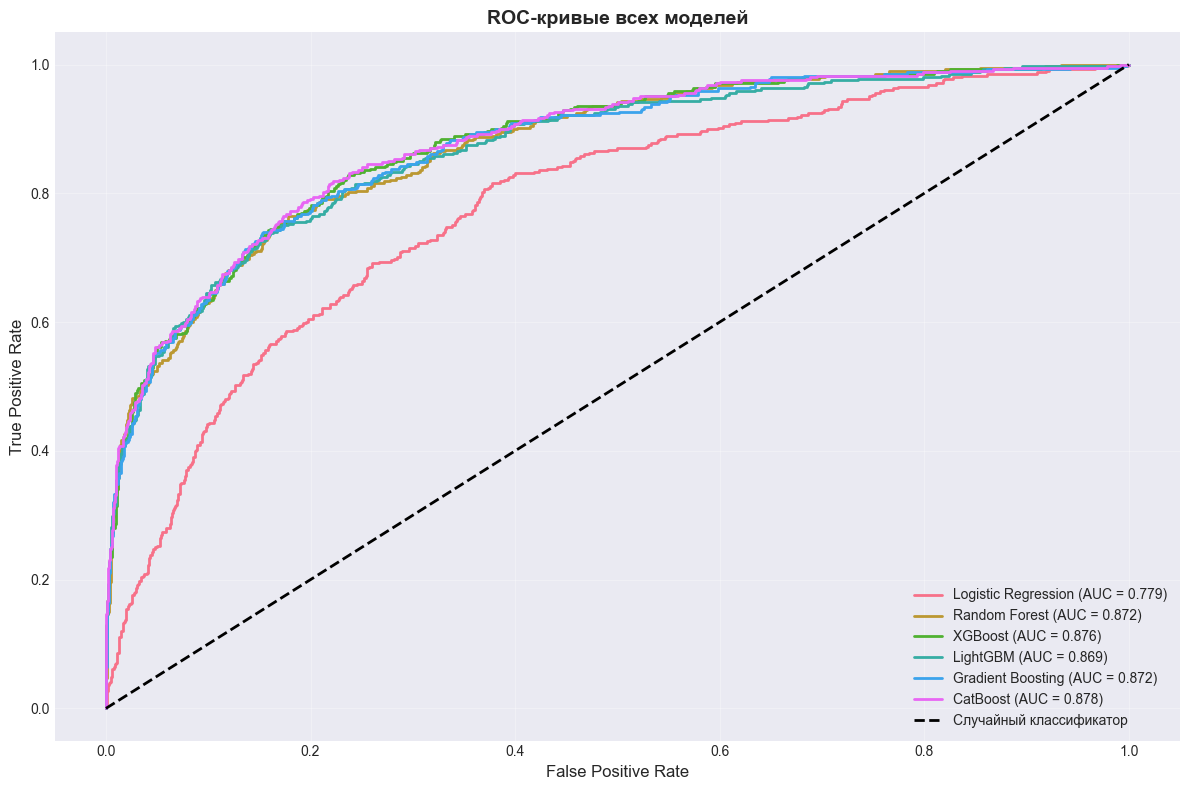

In [24]:
# ROC-кривые не зависят от выбранного порога, потому что строятся по вероятностям.
plt.figure(figsize=(12, 8))

for name, y_proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


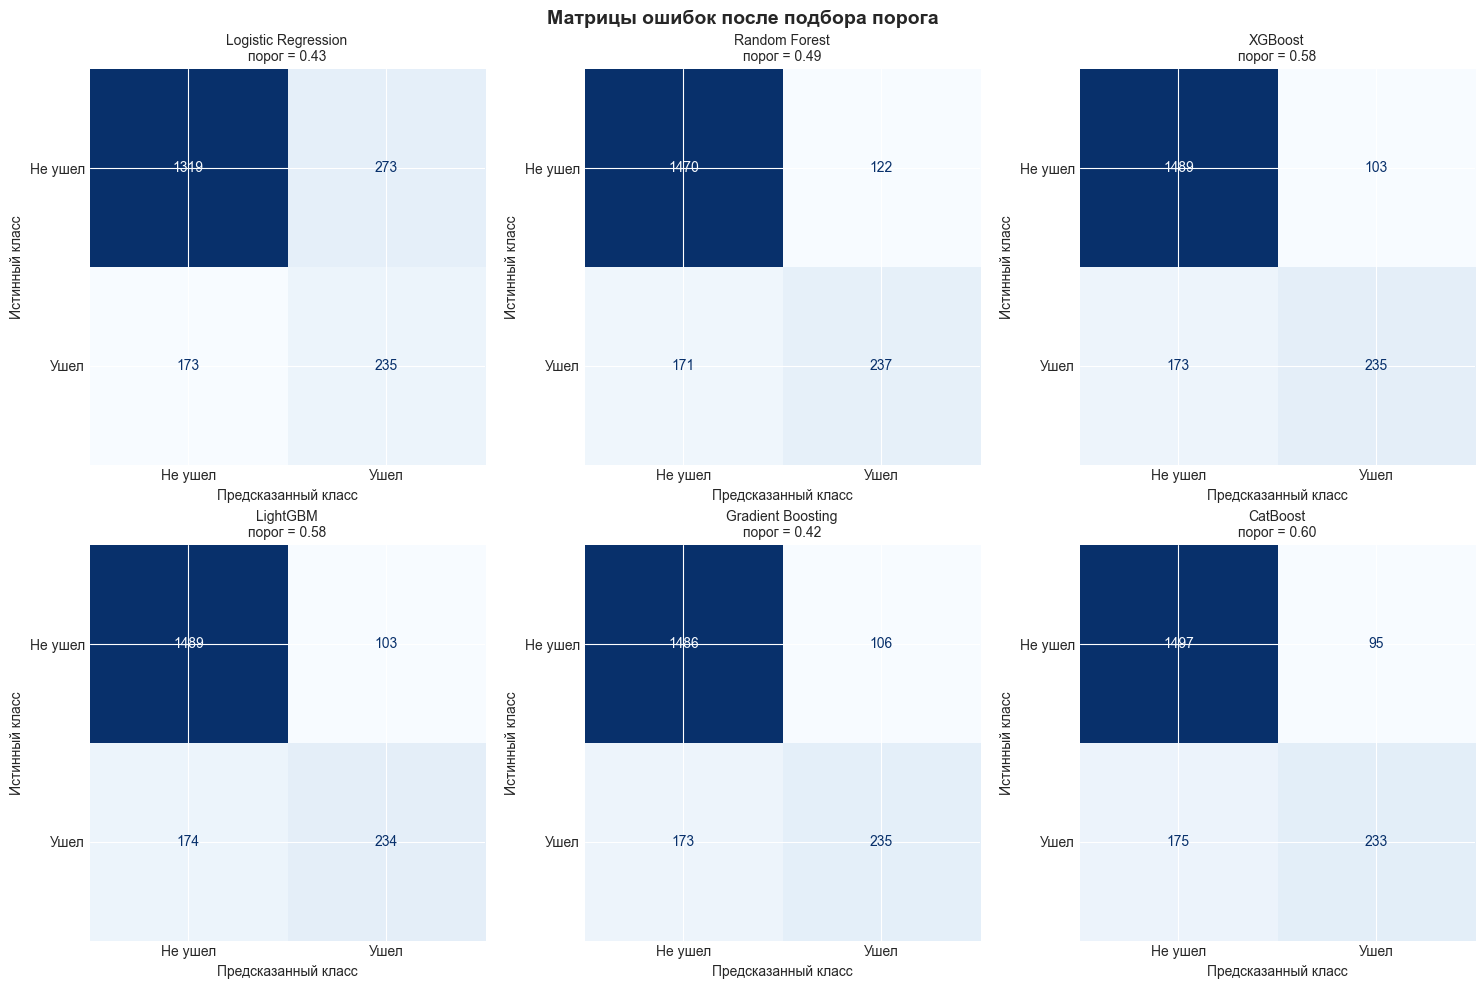

In [25]:
# Матрицы ошибок после подбора порога
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(tuned_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не ушел', 'Ушел'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(f'{name}\nпорог = {tuned_results_df.loc[name, "Threshold"]:.2f}', fontsize=10)
    axes[idx].set_xlabel('Предсказанный класс')
    axes[idx].set_ylabel('Истинный класс')

plt.suptitle('Матрицы ошибок после подбора порога', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
print('\n' + '=' * 60)
print('КРОСС-ВАЛИДАЦИЯ ROC-AUC')
print('=' * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Для Logistic Regression в кросс-валидации используем Pipeline,
# чтобы scaler обучался только на train-fold, без утечки данных.
lr_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight={0: 1, 1: 2}))
])

models_cv = {
    'Logistic Regression': lr_cv,
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'Gradient Boosting': gb,
    'CatBoost': cat
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_full, y_train_full, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name}: CV ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})')

cv_df = pd.DataFrame(cv_results).T



КРОСС-ВАЛИДАЦИЯ ROC-AUC
Logistic Regression: CV ROC-AUC = 0.7653 (+/- 0.0071)
Random Forest: CV ROC-AUC = 0.8615 (+/- 0.0054)
XGBoost: CV ROC-AUC = 0.8652 (+/- 0.0073)
LightGBM: CV ROC-AUC = 0.8603 (+/- 0.0079)
Gradient Boosting: CV ROC-AUC = 0.8607 (+/- 0.0068)
CatBoost: CV ROC-AUC = 0.8657 (+/- 0.0075)


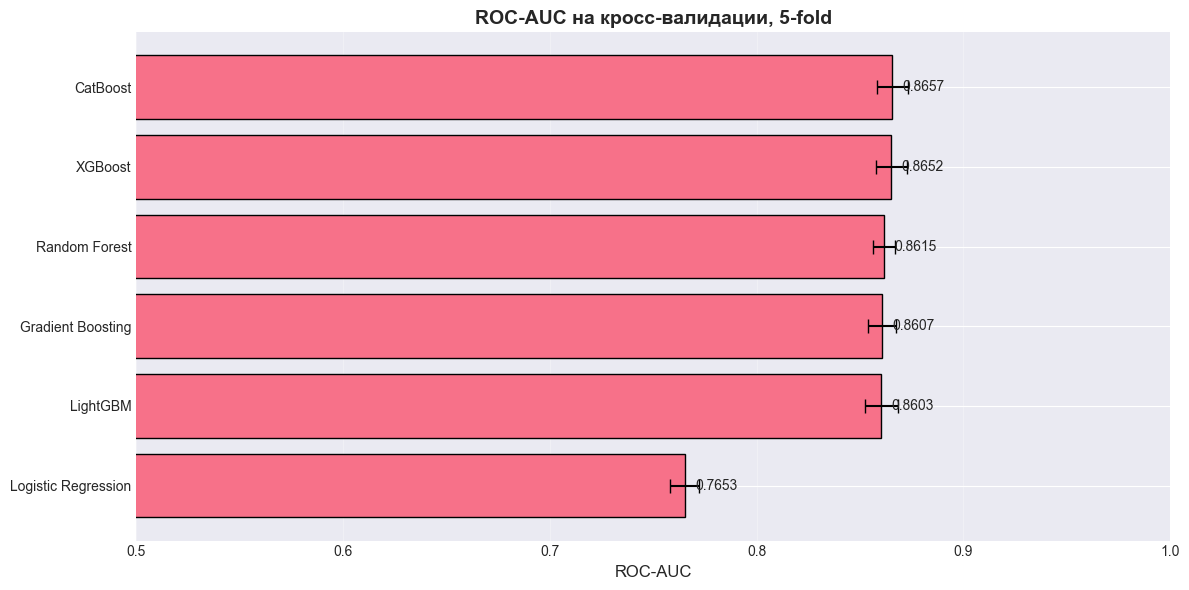

In [27]:
# Сравнение ROC-AUC по кросс-валидации
cv_df_sorted = cv_df.sort_values('mean', ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(cv_df_sorted.index, cv_df_sorted['mean'], xerr=cv_df_sorted['std'], capsize=5, edgecolor='black')
plt.xlabel('ROC-AUC', fontsize=12)
plt.title('ROC-AUC на кросс-валидации, 5-fold', fontsize=14, fontweight='bold')
plt.xlim(0.5, 1.0)
plt.grid(axis='x', alpha=0.3)

for bar, value in zip(bars, cv_df_sorted['mean']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f'{value:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


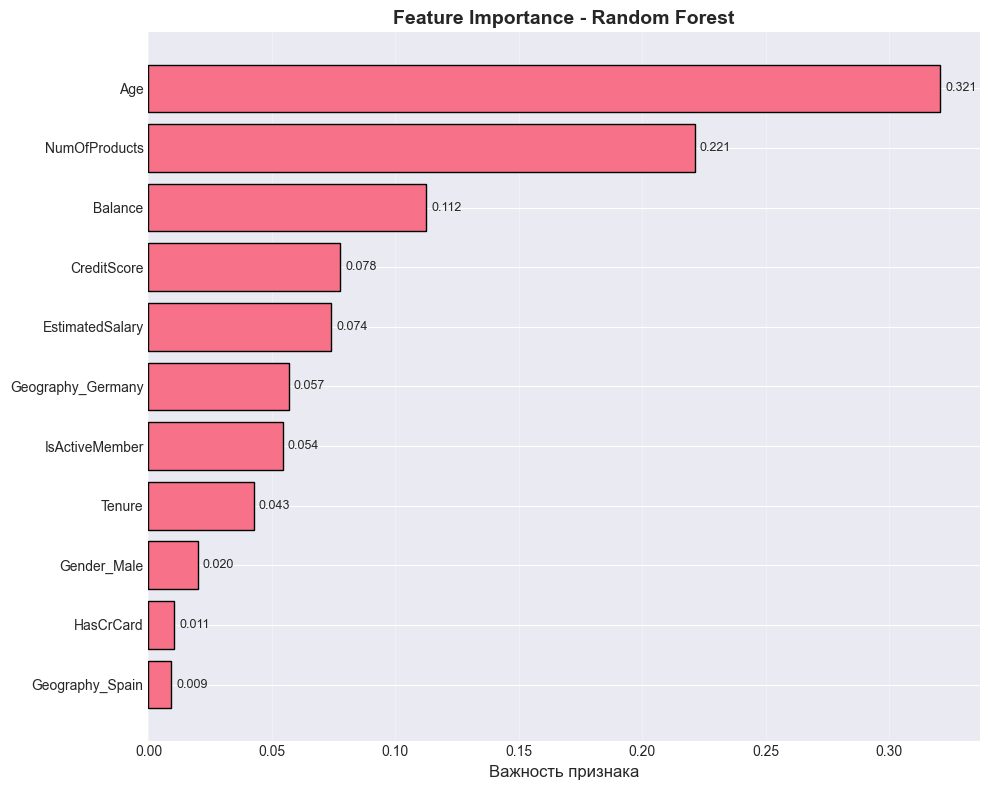

In [28]:
# Feature Importance для Random Forest
feature_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(feature_imp)), feature_imp.values, edgecolor='black')
plt.yticks(range(len(feature_imp)), feature_imp.index)
plt.xlabel('Важность признака', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, feature_imp.values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
print('\n' + '=' * 60)
print('ВЫБОР ЛУЧШЕЙ МОДЕЛИ')
print('=' * 60)

best_precision_model = tuned_results_df['Precision'].idxmax()
best_f1_model = tuned_results_df['F1-Score'].idxmax()
best_roc_auc_model = tuned_results_df['ROC-AUC'].idxmax()
best_cv_model = cv_df['mean'].idxmax()

print(f'Лучшая модель по Precision после подбора порога: {best_precision_model}')
print(f"Precision = {tuned_results_df.loc[best_precision_model, 'Precision']:.4f}")
print(f"Recall = {tuned_results_df.loc[best_precision_model, 'Recall']:.4f}")
print(f"F1-Score = {tuned_results_df.loc[best_precision_model, 'F1-Score']:.4f}")
print(f"Порог = {tuned_results_df.loc[best_precision_model, 'Threshold']:.2f}")

print('\nЛучшая модель по F1-Score после подбора порога:', best_f1_model)
print('Лучшая модель по ROC-AUC на test:', best_roc_auc_model)
print('Лучшая модель по ROC-AUC на cross-validation:', best_cv_model)



ВЫБОР ЛУЧШЕЙ МОДЕЛИ
Лучшая модель по Precision после подбора порога: CatBoost
Precision = 0.7104
Recall = 0.5711
F1-Score = 0.6332
Порог = 0.60

Лучшая модель по F1-Score после подбора порога: CatBoost
Лучшая модель по ROC-AUC на test: CatBoost
Лучшая модель по ROC-AUC на cross-validation: CatBoost

Вывод для отчета:
Низкий Precision у части моделей был связан с дисбалансом классов и слишком сильной балансировкой.
После перехода к мягкой балансировке и подбора порога классификации модель реже ошибочно относит клиентов к ушедшим.
Это повышает Precision, а ROC-AUC при этом не ухудшается, так как ROC-AUC зависит от вероятностей, а не от конкретного порога.
